#### Find E and store it in dataset


In [42]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
import numpy as np

In [29]:
# Ask the user to select a folder containing the data files
root = tk.Tk()
root.withdraw()  # hide the main tkinter window
folder_path = filedialog.askdirectory(title="Please select the folder containing the data files: ")

In [30]:

# Find list of relative paths to .txt files in all the folders and subfolders of the selected folder
txt_files = []
for root_dir, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".txt"):
            txt_files.append(os.path.relpath(os.path.join(root_dir, file), folder_path))


#remove those in Calib folder and those ending with position.txt
txt_files = [f for f in txt_files if "Calib" not in f and not f.endswith("position.txt")]

print("List of filtered .txt files:")
for f in txt_files:
    print(f)
print("\n")

# create a df to store the results
results_df = pd.DataFrame(columns=["Name", "Folder", "Header line", "X", "Y", "Count", "E[eff] (kPa)", "E[v=0.50] (kPa)"])


# read text file tracking line until you find "Time (s)" then memorize that line and call it header_line
for l in range(len(txt_files)):
    path = os.path.join(folder_path, txt_files[l])
    results_df.loc[l, "Folder"] = os.path.dirname(txt_files[l])
    # Name is until "S-" in the filename
    results_df.loc[l, "Name"] = os.path.basename(txt_files[l]).split("S-")[0]
    with open(path, 'r', encoding='latin-1', errors='replace') as f:
        for i, line in enumerate(f):
            if "Time (s)" in line:
                results_df.loc[l, "Header line"] = i
                break
            if "E[eff]" in line:
                results_df.loc[l, "E[eff] (kPa)"] = (float(line.strip().split('\t')[-1]))/1e3
            if "E[v=0.50]" in line:
                results_df.loc[l, "E[v=0.50] (kPa)"] = (float(line.strip().split('\t')[-1]))/1e3
            if i == 2:
                parts = line.strip().split('\t')
                for idx, part in enumerate(parts[:-1]):
                    if part == "X (#)":
                        results_df.loc[l, "X"] = float(parts[idx + 1])
                    elif part == "Y (#)":
                        results_df.loc[l, "Y"] = float(parts[idx + 1])


# Add an index count per folder
results_df["Count"] = results_df.groupby("Folder").cumcount() + 1
display(results_df)

List of filtered .txt files:
A1\Indentations\A1 Indentation_001.txt
A1\Indentations\A1 Indentation_002.txt
A1\Indentations\A1 Indentation_003.txt
A2\Indentations\A2 Indentation_001.txt
A2\Indentations\A2 Indentation_002.txt
A2\Indentations\A2 Indentation_003.txt
A3\Indentations\A3 Indentation_001.txt
A3\Indentations\A3 Indentation_002.txt
A3\Indentations\A3 Indentation_003.txt
A3\Indentations\A3 Indentation_004.txt
A4\Indentations\A4 Indentation_001.txt
A4\Indentations\A4 Indentation_002.txt
A4\Indentations\A4 Indentation_003.txt
A5\Indentations\A5 Indentation_001.txt
A5\Indentations\A5 Indentation_002.txt
A5\Indentations\A5 Indentation_003.txt
A5\Indentations\A5 Indentation_004.txt
A5\Indentations\A5 Indentation_005.txt
A5\Indentations\A5 Indentation_006.txt
A5\Indentations\A5 Indentation_007.txt
B1\Indentations\B1 Indentation_001.txt
B1\Indentations\B1 Indentation_002.txt
B1\Indentations\B1 Indentation_003.txt
B2\Indentations\B2 Indentation_001.txt
B2\Indentations\B2 Indentation_002.

,Name,Folder,Header line,X,Y,Count,E[eff] (kPa),E[v=0.50] (kPa)
0,A1 Indentation_001.txt,A1\Indentations,34,1.0,1.0,1,2.196061,1.647046
1,A1 Indentation_002.txt,A1\Indentations,34,1.0,1.0,2,2.205158,1.653868
2,A1 Indentation_003.txt,A1\Indentations,34,1.0,1.0,3,2.217714,1.663286
3,A2 Indentation_001.txt,A2\Indentations,34,1.0,1.0,1,2.258917,1.694187
4,A2 Indentation_002.txt,A2\Indentations,34,1.0,1.0,2,2.193227,1.64492
...,...,...,...,...,...,...,...,...
66,D5 Indentation_001.txt,D5\Indentations,34,1.0,1.0,1,NaN,NaN
67,D5 Indentation_002.txt,D5\Indentations,34,1.0,1.0,2,NaN,NaN
68,D5 Indentation_003.txt,D5\Indentations,34,1.0,1.0,3,13.552421,10.164316
69,D5 Indentation_004.txt,D5\Indentations,34,1.0,1.0,4,13.37395,10.030462


In [31]:
# Remove outliers where E value is more than 1 GPa (1e6 kPa)
results_df = results_df[(results_df["E[eff] (kPa)"] < 1e6) & (results_df["E[v=0.50] (kPa)"] < 1e6)]

# Remove Nan values
results_df = results_df.dropna(subset=["E[eff] (kPa)", "E[v=0.50] (kPa)"])

# Save the results to a CSV file
results_df.to_csv(os.path.join(folder_path, "results.csv"), index=False)

display(results_df)

,Name,Folder,Header line,X,Y,Count,E[eff] (kPa),E[v=0.50] (kPa)
0,A1 Indentation_001.txt,A1\Indentations,34,1.0,1.0,1,2.196061,1.647046
1,A1 Indentation_002.txt,A1\Indentations,34,1.0,1.0,2,2.205158,1.653868
2,A1 Indentation_003.txt,A1\Indentations,34,1.0,1.0,3,2.217714,1.663286
3,A2 Indentation_001.txt,A2\Indentations,34,1.0,1.0,1,2.258917,1.694187
4,A2 Indentation_002.txt,A2\Indentations,34,1.0,1.0,2,2.193227,1.64492
...,...,...,...,...,...,...,...,...
64,D4 Indentation_002.txt,D4\Indentations,34,1.0,1.0,2,11.041357,8.281017
65,D4 Indentation_003.txt,D4\Indentations,34,1.0,1.0,3,11.130387,8.34779
68,D5 Indentation_003.txt,D5\Indentations,34,1.0,1.0,3,13.552421,10.164316
69,D5 Indentation_004.txt,D5\Indentations,34,1.0,1.0,4,13.37395,10.030462


In [32]:
# Aggregate the results by folder and calculate the mean and standard deviation for E[eff] and E[v=0.50]
aggregated_df = results_df.groupby("Folder").agg({"E[eff] (kPa)": ["mean", "std"], "E[v=0.50] (kPa)": ["mean", "std"]})

display(aggregated_df)


E[eff] (kPa)           E[v=0.50] (kPa)          
                        mean       std            mean       std
Folder                                                          
A1\Indentations     2.206311  0.010872        1.654733  0.008155
A2\Indentations     2.231415  0.034124        1.673561  0.025593
A3\Indentations      2.50658  0.047277        1.879935  0.035458
A4\Indentations     2.428125  0.199811        1.821094  0.149858
A5\Indentations     2.309528  0.086610        1.732146  0.064957
B1\Indentations     5.421523  0.044794        4.066142  0.033596
B2\Indentations     6.099584  0.207093        4.574688  0.155320
B3\Indentations     6.952234  0.059602        5.214175  0.044702
B4\Indentations     7.233845  0.048863        5.425383  0.036647
B5\Indentations     7.702664  0.085846        5.776998  0.064384
C1\Indentations     6.911074  0.111232        5.183305  0.083423
C2\Indentations     7.780085  0.042139        5.835064  0.031604
C3\Indentations     8.927598  0.109845        6.695699  0.082384
C4\Indentations      9.87039  0.052887        7.402792  0.039666
C5\Indentations    10.649158  0.340686        7.986869  0.255514
D1\Indentations     8.042517  0.330041        6.031888  0.247531
D2\Indentations      8.72824  0.135314         6.54618  0.101485
D3\Indentations    10.152818  0.100652        7.614614  0.075490
D4\Indentations    11.099305  0.050229        8.324479  0.037672
D5\Indentations     13.40679  0.132304       10.055092  0.099228

In [44]:
# Create mapping from well name to folder
M = [["A1", "A2", "A3", "A4", "A5", "A6"],
    ["B1", "B2", "B3", "B4", "B5", "B6"],
    ["C1", "C2", "C3", "C4", "C5", "C6"],
    ["D1", "D2", "D3", "D4", "D5", "D6"]]
#well_plate = pd.DataFrame(M, columns=["1", "2", "3", "4", "5", "6"], index=["A", "B", "C", "D"])
well_plate = pd.DataFrame(M, columns=["4%", "4.25%", "4.5%", "4.75%", "5%", ""], index=["1", "2", "3", "4"])
Eeff_matrix = pd.DataFrame(np.nan, index=well_plate.index, columns=well_plate.columns, dtype=float)
Eeff_std_matrix = pd.DataFrame(np.nan, index=well_plate.index, columns=well_plate.columns, dtype=float)
E05_matrix = pd.DataFrame(np.nan, index=well_plate.index, columns=well_plate.columns, dtype=float)
E05_std_matrix = pd.DataFrame(np.nan, index=well_plate.index, columns=well_plate.columns, dtype=float)
well_to_folder = {}
for folder in aggregated_df.index:
    well_name = folder.split('\\')[0]  # Extract well name (e.g., 'A1', 'B2')
    well_to_folder[well_name] = folder

for r in range(len(M)):
    for c in range(len(M[0])):
        well_name = M[r][c]
        if well_name in well_to_folder:
            folder = well_to_folder[well_name]
            Eeff_matrix.iloc[r, c] = aggregated_df.loc[folder, ("E[eff] (kPa)", "mean")]
            Eeff_std_matrix.iloc[r, c] = aggregated_df.loc[folder, ("E[eff] (kPa)", "std")]
            E05_matrix.iloc[r, c] = aggregated_df.loc[folder, ("E[v=0.50] (kPa)", "mean")]
            E05_std_matrix.iloc[r, c] = aggregated_df.loc[folder, ("E[v=0.50] (kPa)", "std")]

display(Eeff_matrix)
display(E05_matrix)


,4%,4.25%,4.5%,4.75%,5%,
1,2.206311,2.231415,2.506580,2.428125,2.309528,NaN
2,5.421523,6.099584,6.952234,7.233845,7.702664,NaN
3,6.911074,7.780085,8.927598,9.870390,10.649158,NaN
4,8.042517,8.728240,10.152818,11.099305,13.406790,NaN


,4%,4.25%,4.5%,4.75%,5%,
1,1.654733,1.673561,1.879935,1.821094,1.732146,NaN
2,4.066142,4.574688,5.214175,5.425383,5.776998,NaN
3,5.183305,5.835064,6.695699,7.402792,7.986869,NaN
4,6.031888,6.546180,7.614614,8.324479,10.055092,NaN


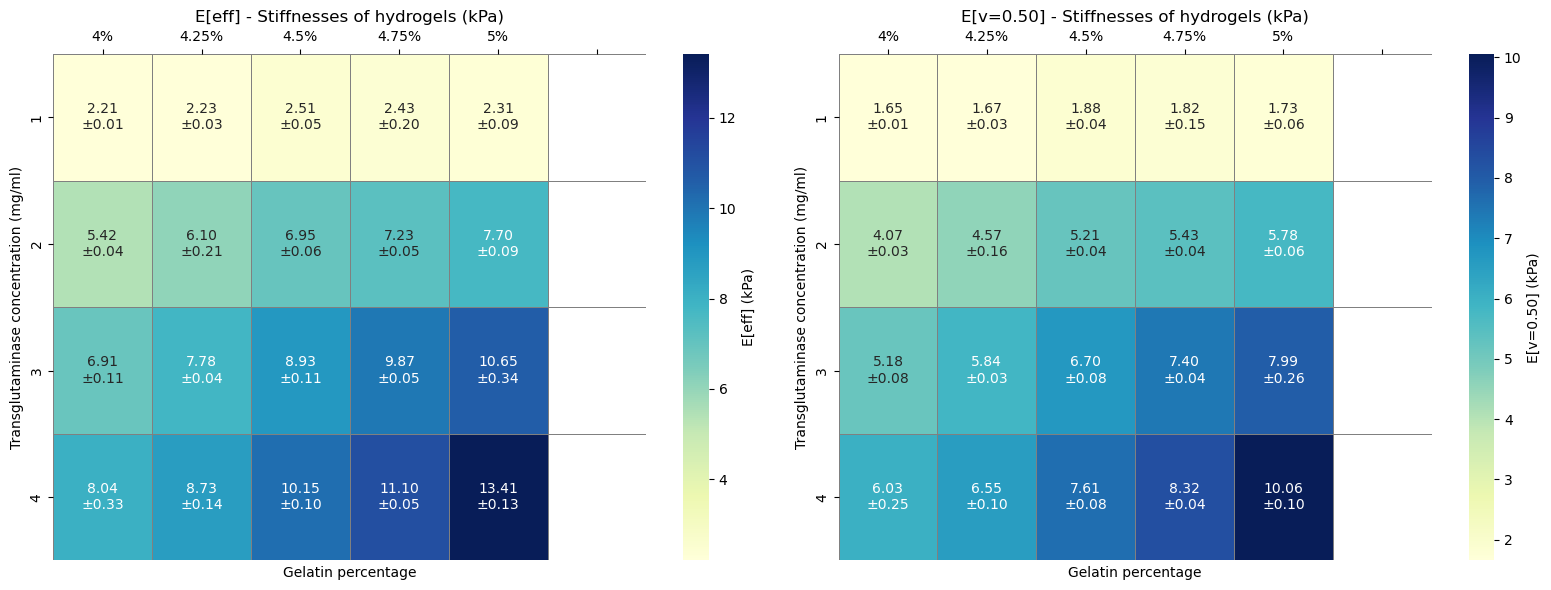

In [52]:
def make_annot_matrix(matrix, std_matrix):
    annot = matrix.copy().astype(str)
    for r in matrix.index:
        for c in matrix.columns:
            val = matrix.loc[r, c]
            if pd.notna(val):
                std_val = std_matrix.loc[r, c]
                if pd.notna(std_val):
                    annot.loc[r, c] = f"{val:.2f}\n±{std_val:.2f}"
                else:
                    annot.loc[r, c] = f"{val:.2f}"
            else:
                annot.loc[r, c] = ""
    return annot

annot_eeff = make_annot_matrix(Eeff_matrix, Eeff_std_matrix)
annot_e05 = make_annot_matrix(E05_matrix, E05_std_matrix)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Plot Eeff_matrix
sns.heatmap(
    Eeff_matrix.astype(float),
    annot=annot_eeff,
    fmt="",
    cmap="YlGnBu",
    cbar_kws={"label": "E[eff] (kPa)"},
    ax=axes[0],
    linewidths=0.5,
    linecolor="gray"
)
axes[0].set_xlabel("Gelatin percentage")
axes[0].set_ylabel("Transglutaminase concentration (mg/ml)")
axes[0].xaxis.tick_top()
axes[0].set_title("E[eff] - Stiffnesses of hydrogels (kPa)")

# Plot E05_matrix
sns.heatmap(
    E05_matrix.astype(float),
    annot=annot_e05,
    fmt="",
    cmap="YlGnBu",
    cbar_kws={"label": "E[v=0.50] (kPa)"},
    ax=axes[1],
    linewidths=0.5,
    linecolor="gray"
)
axes[1].set_xlabel("Gelatin percentage")
axes[1].set_ylabel("Transglutaminase concentration (mg/ml)")
axes[1].xaxis.tick_top()
axes[1].set_title("E[v=0.50] - Stiffnesses of hydrogels (kPa)")

plt.tight_layout()
plt.show()



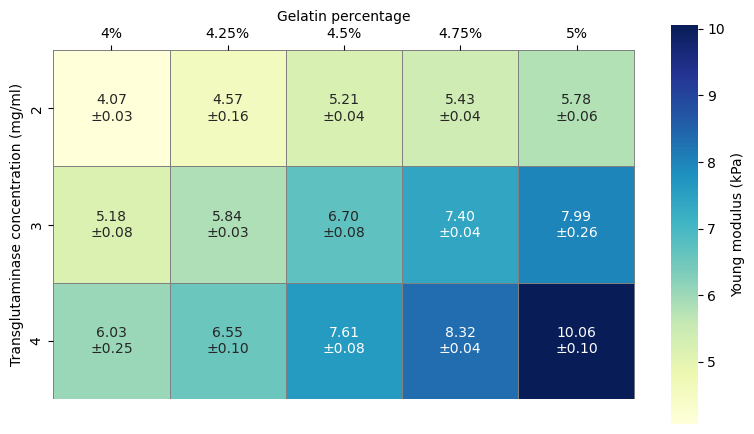

In [100]:

def truncate_matrix(matrix):
    # remove the first/top row
    matrix = matrix.drop(index=matrix.index[0])
    # remove the last column
    matrix = matrix.drop(columns=matrix.columns[-1])
    return matrix


# plot heatmap of truncated matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.heatmap(
    truncate_matrix(E05_matrix).astype(float),
    annot=truncate_matrix(annot_e05),
    fmt="",
    cmap="YlGnBu",
    cbar_kws={"label": "Young modulus (kPa)", "shrink": 0.7, "aspect": 15},
    ax=ax,
    linewidths=0.5,
    linecolor="gray",
    square=True
)

# Add the missing grey line on the far right boundary
ax.axvline(x=truncate_matrix(E05_matrix).shape[1], color="gray", linewidth=2)

ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("Gelatin percentage")
ax.set_ylabel("Transglutaminase concentration (mg/ml)")
ax.xaxis.tick_top()

plt.tight_layout()
plt.show()

